RED DE TELECOMUNICACIONES
Cada nodo tiene comunicacion directa direccionada con otros 2 nodos.

Relaciones direccionadas:
Router Core ---> Switch Central
Router Core ---> Firewall
Switch Central ---> Servidor DNS
Switch Central ---> Antena BTS
Servidor DNS ---> Router Core
Servidor DNS ---> Radioenlace
Firewall ---> Switch Central
Firewall ---> Central Telefonica
Antena BTS ---> Radioenlace
Antena BTS ---> Cliente Final
Radioenlace ---> Router Core
Radioenlace ---> Central Telefonica
Central Telefonica ---> Servidor DNS
Central Telefonica ---> Cliente Final
Cliente Final ---> Firewall
Cliente Final ---> Antena BTS

Matriz de adyacencia:
1 = existe comunicacion directa
0 = no existe comunicacion directa

                        N1 N2 N3 N4 N5 N6 N7 N8 
N1 Router Core          0  1  0  1  0  0  0  0  
N2 Switch Central       0  0  1  0  1  0  0  0  
N3 Servidor DNS         1  0  0  0  0  1  0  0  
N4 Firewall             0  1  0  0  0  0  1  0  
N5 Antena BTS           0  0  0  0  0  1  

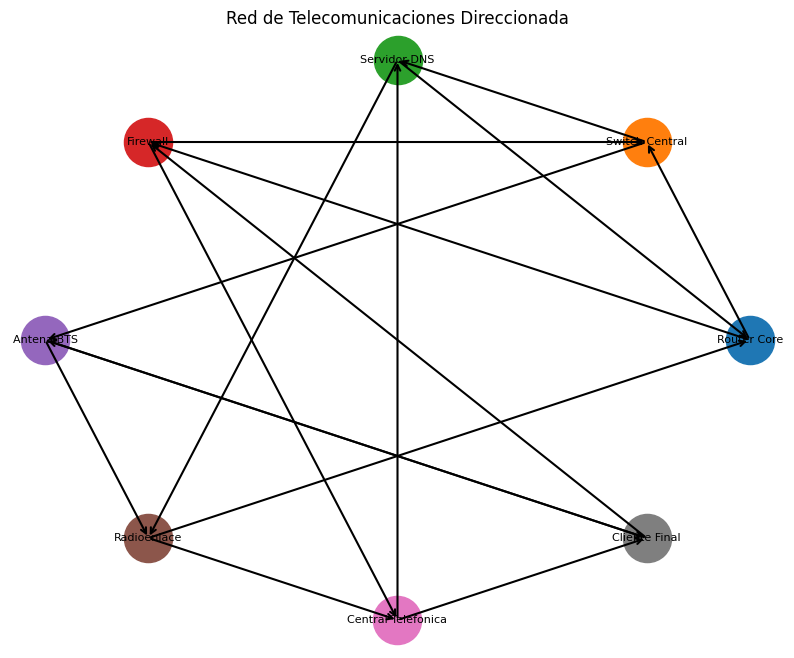

In [1]:
# Ejercicio 10 - Redes y Comunicación
# Trabajo Final Integrador de Programación 2026
# Red direccionada de 8 nodos.
# Cada nodo tiene comunicación directa con otros 2 nodos.

import matplotlib.pyplot as plt
import math

nodos = [
    "Router Core",
    "Switch Central",
    "Servidor DNS",
    "Firewall",
    "Antena BTS",
    "Radioenlace",
    "Central Telefonica",
    "Cliente Final"
]

relaciones = {
    "Router Core": ["Switch Central", "Firewall"],
    "Switch Central": ["Servidor DNS", "Antena BTS"],
    "Servidor DNS": ["Router Core", "Radioenlace"],
    "Firewall": ["Switch Central", "Central Telefonica"],
    "Antena BTS": ["Radioenlace", "Cliente Final"],
    "Radioenlace": ["Router Core", "Central Telefonica"],
    "Central Telefonica": ["Servidor DNS", "Cliente Final"],
    "Cliente Final": ["Firewall", "Antena BTS"]
}

print("RED DE TELECOMUNICACIONES")
print("Cada nodo tiene comunicacion directa direccionada con otros 2 nodos.")
print("")

print("Relaciones direccionadas:")
for origen, destinos in relaciones.items():
    for destino in destinos:
        print(origen + " ---> " + destino)

print("")
print("Matriz de adyacencia:")
print("1 = existe comunicacion directa")
print("0 = no existe comunicacion directa")
print("")

matriz = []

for origen in nodos:
    fila = []
    for destino in nodos:
        if destino in relaciones[origen]:
            fila.append(1)
        else:
            fila.append(0)
    matriz.append(fila)

# Mostrar encabezado de la matriz
encabezado = " " * 24
for i in range(len(nodos)):
    encabezado = encabezado + "N" + str(i + 1) + " "

print(encabezado)

# Mostrar matriz de adyacencia
for i in range(len(matriz)):
    fila_texto = "N" + str(i + 1) + " " + nodos[i].ljust(20) + " "

    for valor in matriz[i]:
        fila_texto = fila_texto + str(valor) + "  "

    print(fila_texto)

# Dibujar la red
posiciones = {}
radio = 3
cantidad = len(nodos)

for i in range(cantidad):
    nodo = nodos[i]
    angulo = 2 * math.pi * i / cantidad
    x = radio * math.cos(angulo)
    y = radio * math.sin(angulo)
    posiciones[nodo] = (x, y)

plt.figure(figsize=(10, 8))

# Dibujar nodos
for nodo in nodos:
    x, y = posiciones[nodo]
    plt.scatter(x, y, s=1200)
    plt.text(x, y, nodo, ha="center", va="center", fontsize=8)

# Dibujar flechas
for origen, destinos in relaciones.items():
    x1, y1 = posiciones[origen]

    for destino in destinos:
        x2, y2 = posiciones[destino]

        plt.annotate(
            "",
            xy=(x2, y2),
            xytext=(x1, y1),
            arrowprops=dict(arrowstyle="->", lw=1.5)
        )

plt.title("Red de Telecomunicaciones Direccionada")
plt.axis("off")
plt.show()